LEAST-SQUARES FIT DEFINITION
Fitting interval : [0, 80]
Time points      : 10001
Weighting        : uniform
Error function   : [Re(C_fit-C), Im(C_fit-C)]
Initial guess    : [0.5, 1.0, 1.0, 0.0, 1.0]
Optimizer status : ier = 3 (Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000 and the relative error between two consecutive iterates is at 
  most 0.000000)

FITTED PARAMETERS AND FORMAL 1-SIGMA ERRORS
eta_plus   = (0.8281984357742752+0.2666362916403339j)
  SE[Re, Im] = [1.581808e-05, 1.862820e-05]
eta_minus  = (0.2515345253822025-0.2666362916403339j)
  SE[Re, Im] = [1.323426e-05, 1.862820e-05]
gamma_plus = (0.49939896695175917+0.8670217872367086j)
  SE[Re, Im] = [1.271292e-05, 1.401545e-05]
gamma_minus= (0.49939896695175917-0.8670217872367086j)
  SE[Re, Im] = [1.271292e-05, 1.401545e-05]

EFFECTIVE PARAMETERS
Omega_bar = (1.000562895442171+0j)
zeta_bar  = (0.9987979339035183+0j)
delta0    = (0.08029553992562366+0j)
delta1    = 0.07681533814123918
d

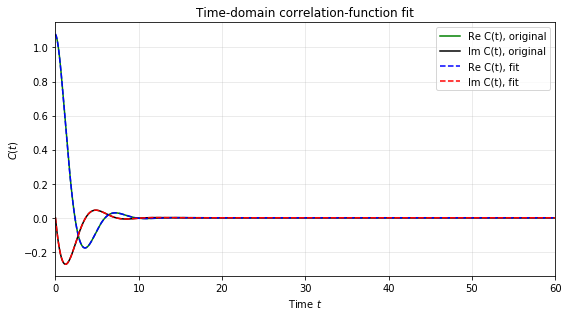

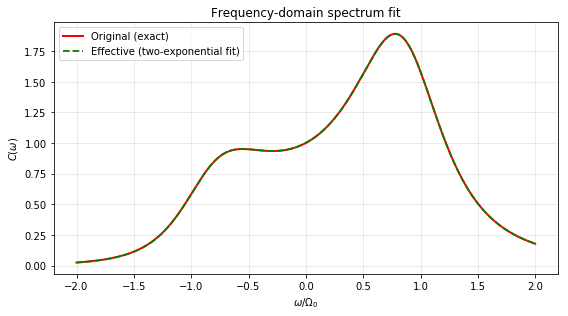

In [2]:
 #上传github的拟合代码

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from scipy.optimize import leastsq
from deom import decompose_spe

# Input parameters used for the first parameter set in Table I
BETA = 1.0
NPSD = 1500
OMEGA0 = 1.0
ZETA0 = 1.0
DELTA = 5.0

# Fitting grid and optimizer settings
T_MIN = 0.0
T_MAX = 80.0
N_TIME = 10001
INITIAL_GUESS = np.array([0.5, 1.0, 1.0, 0.0, 1.0], dtype=float)
MAXFEV = 20000


def two_exponential_model(parameters, time):
    a, b, c, d, e = parameters
    root_b = np.sqrt(b + 0j)
    gamma_plus = a + 1j * root_b
    gamma_minus = a - 1j * root_b
    eta_plus = c + 1j * d
    eta_minus = e - 1j * d
    model = (eta_plus * np.exp(-gamma_plus * time)
             + eta_minus * np.exp(-gamma_minus * time))
    return model, gamma_plus, gamma_minus, eta_plus, eta_minus

# Generate the original correlation function C(t) with DEOM.
w = sp.symbols("w", real=True)
Omega = sp.symbols("Omega", positive=True)
zeta = sp.symbols("zeta", positive=True)
spectrum = Omega / (Omega**2 - w**2 - sp.I * w * zeta)

etal, etar, etaa, expn = decompose_spe(
    spectrum, w,
    {Omega: OMEGA0, zeta: ZETA0},
    {"beta": BETA},
    {}, NPSD
)

time = np.linspace(T_MIN, T_MAX, N_TIME)
correlation = np.zeros(N_TIME, dtype=complex)
for coefficient, exponent in zip(etal, expn):
    correlation += coefficient * np.exp(-exponent * time)

# Uniform weighting: real and imaginary residual components enter equally.
def residual(parameters):
    difference = two_exponential_model(parameters, time)[0] - correlation
    return np.concatenate((difference.real, difference.imag))

parameters, cov_x, info, message, ier = leastsq(
    residual, INITIAL_GUESS, full_output=True, maxfev=MAXFEV
)
if ier not in (1, 2, 3, 4):
    raise RuntimeError("Least-squares fit failed: " + str(message))

a, b, c, d, e = parameters
if b <= 0.0:
    raise RuntimeError("The fitted b must be positive for this parametrization.")

model_fit, gamma_plus, gamma_minus, eta_plus, eta_minus = (
    two_exponential_model(parameters, time)
)
error = model_fit - correlation
sse = float(np.sum(np.abs(error)**2))
dof = 2 * N_TIME - len(parameters)
rmse = float(np.sqrt(sse / N_TIME))
max_abs_error = float(np.max(np.abs(error)))
relative_l2_error = float(np.linalg.norm(error) / np.linalg.norm(correlation))

# Formal local 1-sigma errors under the uniform independent-residual assumption.
if cov_x is None or dof <= 0:
    parameter_std = np.full(5, np.nan)
else:
    covariance = cov_x * (sse / dof)
    parameter_std = np.sqrt(np.maximum(np.diag(covariance), 0.0))
std_a, std_b, std_c, std_d, std_e = parameter_std
std_frequency = std_b / (2.0 * np.sqrt(b))

# Derived effective parameters.
zeta_bar = gamma_plus + gamma_minus
Omega_bar = 0.5 * np.sqrt(zeta_bar**2 - (gamma_plus - gamma_minus)**2)
moment = (eta_plus * gamma_plus + eta_minus * gamma_minus) / Omega_bar
delta2 = 2.0 * moment.imag - 1.0
delta0 = np.real(eta_plus + eta_minus) - 1.0 / (BETA * Omega_bar)
delta1 = np.real(moment)
omega_eff = np.sqrt(Omega_bar**2 - zeta_bar**2 / 4.0)
g_eff_over_g = (1.0 + delta2 / 2.0) * np.sqrt(Omega_bar / omega_eff)
g_c = omega_eff * np.sqrt(
    1.0 + np.sqrt(1.0 + DELTA**2 / (16.0 * omega_eff**2))
)

print("=" * 78)
print("LEAST-SQUARES FIT DEFINITION")
print("=" * 78)
print("Fitting interval : [{:.6g}, {:.6g}]".format(T_MIN, T_MAX))
print("Time points      : {}".format(N_TIME))
print("Weighting        : uniform")
print("Error function   : [Re(C_fit-C), Im(C_fit-C)]")
print("Initial guess    : {}".format(INITIAL_GUESS.tolist()))
print("Optimizer status : ier = {} ({})".format(ier, message))

print("\n" + "=" * 78)
print("FITTED PARAMETERS AND FORMAL 1-SIGMA ERRORS")
print("=" * 78)
print("eta_plus   = {}".format(eta_plus))
print("  SE[Re, Im] = [{:.6e}, {:.6e}]".format(std_c, std_d))
print("eta_minus  = {}".format(eta_minus))
print("  SE[Re, Im] = [{:.6e}, {:.6e}]".format(std_e, std_d))
print("gamma_plus = {}".format(gamma_plus))
print("  SE[Re, Im] = [{:.6e}, {:.6e}]".format(std_a, std_frequency))
print("gamma_minus= {}".format(gamma_minus))
print("  SE[Re, Im] = [{:.6e}, {:.6e}]".format(std_a, std_frequency))

print("\n" + "=" * 78)
print("EFFECTIVE PARAMETERS")
print("=" * 78)
print("Omega_bar = {}".format(Omega_bar))
print("zeta_bar  = {}".format(zeta_bar))
print("delta0    = {}".format(delta0))
print("delta1    = {}".format(delta1))
print("delta2    = {}".format(delta2))
print("omega_eff = {}".format(omega_eff))
print("g_eff/g   = {}".format(g_eff_over_g))
print("g_c       = {}".format(g_c))

print("\n" + "=" * 78)
print("FIT QUALITY")
print("=" * 78)
print("SSE                    = {:.14e}".format(sse))
print("RMSE (complex samples) = {:.14e}".format(rmse))
print("Maximum |C_fit-C|      = {:.14e}".format(max_abs_error))
print("Relative L2 error      = {:.14e}".format(relative_l2_error))

# Time-domain validation figure (display only).
plt.figure(figsize=(8.0, 4.5))
plt.plot(time, correlation.real, "green", label="Re C(t), original")
plt.plot(time, correlation.imag, "k", label="Im C(t), original")
plt.plot(time, model_fit.real, "b--", label="Re C(t), fit")
plt.plot(time, model_fit.imag, "r--", label="Im C(t), fit")
plt.xlabel("Time $t$")
plt.ylabel("$C(t)$")
plt.xlim(T_MIN, 60.0)
plt.title("Time-domain correlation-function fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Frequency-domain validation figure. The analytic omega -> 0 limit affects
# only this displayed curve; it is not used in the least-squares fit.
omega = np.linspace(-2.0 * OMEGA0, 2.0 * OMEGA0, 1001)
chi = OMEGA0 / (OMEGA0**2 - omega**2 - 1j * omega * ZETA0)
denominator = -np.expm1(-BETA * omega)
exact_spectrum = np.empty_like(omega)
nonzero = np.abs(omega) > 1.0e-10
exact_spectrum[nonzero] = np.imag(chi[nonzero]) / denominator[nonzero]
exact_spectrum[~nonzero] = ZETA0 / (BETA * OMEGA0**3)
fitted_spectrum = np.real(
    eta_plus / (gamma_plus - 1j * omega)
    + eta_minus / (gamma_minus - 1j * omega)
)

plt.figure(figsize=(8.0, 4.5))
plt.plot(omega / OMEGA0, exact_spectrum, color="red", linewidth=2.0,
         label="Original (exact)")
plt.plot(omega / OMEGA0, fitted_spectrum, "--", color="green",
         linewidth=1.8, label="Effective (two-exponential fit)")
plt.xlabel(r"$\omega/\Omega_0$")
plt.ylabel(r"$C(\omega)$")
plt.title("Frequency-domain spectrum fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


